# 5. Методы повторной выборки.

Упражнения из **5 главы** книги [Введение в статистическое обучение](http://www-bcf.usc.edu/~gareth/ISL/) Гарета Джеймса, Даниела Уиттена, Тревора Хасти, Роберта Тибширани, Джонатана Тейлора.

## Теоритические задания.

## Задание 2.

Теперь мы определим вероятность того, что заданное наблюдение является частью бутстреп-выборки. Представи, что у нас есть бутстреп-выборка, полученная из набора данных, состоящего из n наблюдений.

(a) Какова вероятность того, что первое наблюдение в бутстреп-выборке не является j-м наблюдением из исходного набора?

Вероятность того, что j-ое наблюдение попало в выборку на первом шаге равна $\frac{1}{n} => (1 - \frac{1}{n}) - $ вероятность того j-oe наблюдение не папола в выборку на n шаге.

Вероятность того, что j-ое наблюдение не попало в выборку за n шагов $((1 - \frac{1}{n})^n => (1 - (1 - \frac{1}{n})^n) - $ вероятность того j-oe наблюдение папола в выборку за n шагов.

Теперь найдем вероятность того, что j-oe наблюдение находится на первом месте. 

Число благоприятных исходов: $1 * n^{n-1}$

Всего исходов: $n^n$

Значит искомая вероятность равна: $\frac {n^{n-1}}{n^n} = \frac{1}{n} => \frac{n-1}{n} - $ вероятность того, что j-ый элемент не будет на первом месте

Вероятность того, что j-ое значение будет в бутстреп-выборке и оно не является первым равна: $ \frac{n-1}{n} * (1 - (1 - \frac{1}{n})^n)$

Итак вероятность того, что j-наблюдение не является первым равна: $ \frac{n-1}{n} * (1 - (1 - \frac{1}{n})^n) + ((1 - \frac{1}{n})^n$

(b) Какова вероятность того, что второе наблюдение в бутстреп-выборке не является j-м наблюдением их исходного набора?

Ответ анологичен полученному в пункте (a), то есть: $ \frac{n-1}{n} * (1 - (1 - \frac{1}{n})^n) + ((1 - \frac{1}{n})^n$

(c) Докажите, что вероятность отсутствия j-го наблюдение в бутстреп-выборке составляет $(1 - \frac{1}{n})^n $.

Данный пункт доказан выше.

(d) При n = 5 какова вероятность того, что j-e наблюдение окажется в бутстреп-выборке?

Овет: $0.67232$

(e) При n = 100 какова вероятность того, что j-e наблюдение окажется в бутстреп-выборке?

Овет: $0.63397$

(f) При n = 100 какова вероятность того, что j-e наблюдение окажется в бутстреп-выборке?

Овет: $0.63213$

(g) Постройте график, отражающий для всех целых чисел в интервале от 1 до 100 000 вероятность вхождения j-го наблюдения в бутстреп-выборку.

In [22]:
import matplotlib.pyplot as plt

In [23]:
start = 1
end = 10**5

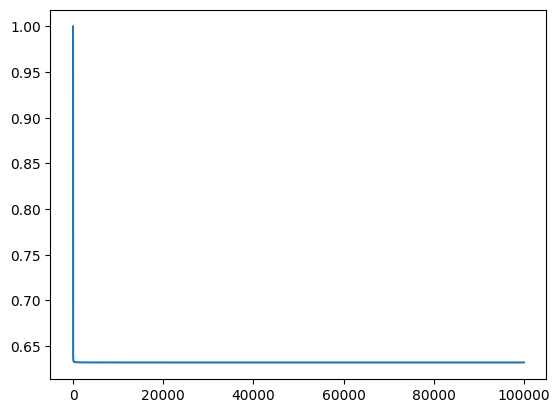

In [24]:
plt.plot([i for i in range(start, end + 1)], [1 - (1 - 1/i)**i for i in range(start, end + 1)])

По графику видно, что вероятность выходит на плато где-то в районе 0.63.

(h) Теперь количествененое исследуем вероятность того, что бутстреп-выборка объемом n = 100 элементов содержит j-e наблюдение. Пусть j=4.

In [25]:
import numpy as np

In [28]:
rng = np.random.default_rng(10)
store = np.empty(10**4)

for i in range(10**4):
    store[i] = np.sum(rng.choice(100, size = 100, replace = True) == 4) > 0

np.mean(store)

0.6362

## Задание 3.

Теперь обратимся к методу k-кратной перекрестной проверки.

(a) Объясните принципы работы и реализации метода k-кратной перекрестной проверки.

Метод k-кратной перекрестной проверки предполагает случайное разделение исходного набора наблюдений на k групп приблизительного равного размера. Первый блок используется в качестве проверочного набора, а обучение выполняется на оставшихся k-1 блоках. После этого вычисляется MSE на проверечных наблюдениях из удержанного блока. Эта процедура повторяется k раз, при этом каждый раз новый блок наблюдений используется в качестве проверочного. Потом результаты полученных моделей усредняеются.В результате мы обучаем и тестируем модель на всем наборе данных.

(b) Каковы приемущества и недостатки метода k-кратной перекрестной проверки по сравнению:
i) с методом проверочный выборки;
Ответ: метод более устойчив к разбиению данных
ii) LOOCV.
Ответ: модель обучается быстрее.

## Задание 4.

Пердставим, что мы используем некий метод статистического обучения для предсказания отклика Y для задданного значения пердиктора X. Поясните в деталях, как бы мы могли произвести оценку стандартного отклоенения предсказанного значения.

Шаги оценки стандартного отклонения через бутстрэппинг:

1) Сгенирировать B бутстрэппироваеых подвыборок из данных.
2) Обучить модель на каждой бутстрэппированной выборке. Это создаст B различных моделей $M_{1}, M{2}, ..., M_{B}$.
3) Сделать предсказания для этих моделей $\hat{Y_{1}}, \hat{Y_{2}}, ..., \hat{Y_{B}}$ на какой-нибудь выборке $X_{new}$.
4) Вычислить мат ожидание предсказаний: $\bar{Y} = \frac{1}{B}\sum \limits _{i=1} ^{B} {Y_{i}}$
5) Рассчитыаем несмещенное стандартное отклонение: $\hat \sigma = \sqrt{\frac{1}{B-1} \sum \limits _{i=1} ^B {(\hat Y_{i} - \bar{Y})^2}} $